In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/Users/ravihw18/ML-Algorithms/11-ANN/11.1-ANN_Regression/powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT = temperature
#V = vacuum
#AP = pressure
#RH = humidity

#PE = produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE", axis=1)
y=df["PE"]

In [8]:
# split our data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)


In [13]:
import torch
import torch.nn as nn

X_train_tensor= torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor= torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset =TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader= DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=32)

In [16]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [17]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [18]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205807.40748697918 & val loss = 204065.265625
epoch 2/100 ==> train loss = 198983.21263020832 & val loss = 190858.296875
epoch 3/100 ==> train loss = 176802.29733072917 & val loss = 159601.671875
epoch 4/100 ==> train loss = 137342.59397786457 & val loss = 114080.7890625
epoch 5/100 ==> train loss = 90279.07317708334 & val loss = 68600.7578125
epoch 6/100 ==> train loss = 51028.96743164062 & val loss = 37301.7578125
epoch 7/100 ==> train loss = 28523.97138671875 & val loss = 22518.15625
epoch 8/100 ==> train loss = 19184.838834635415 & val loss = 16720.080078125
epoch 9/100 ==> train loss = 15146.580244954426 & val loss = 13601.23828125
epoch 10/100 ==> train loss = 12528.45833943685 & val loss = 11174.2470703125
epoch 11/100 ==> train loss = 10196.878253173829 & val loss = 9014.4521484375
epoch 12/100 ==> train loss = 8161.635167439778 & val loss = 7108.8662109375
epoch 13/100 ==> train loss = 6370.614048258463 & val loss = 5445.330078125
epoch 14/100 ==> 

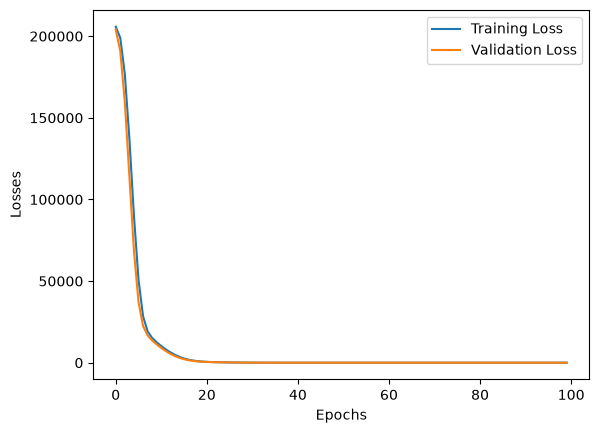

In [19]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [20]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>